In [1]:
# cloud = 0
# clear = 1
import numpy as np
import pylab as plt
import astroML.stats
from tqdm.notebook import tqdm

  0%|          | 0/99999 [00:00<?, ?it/s]

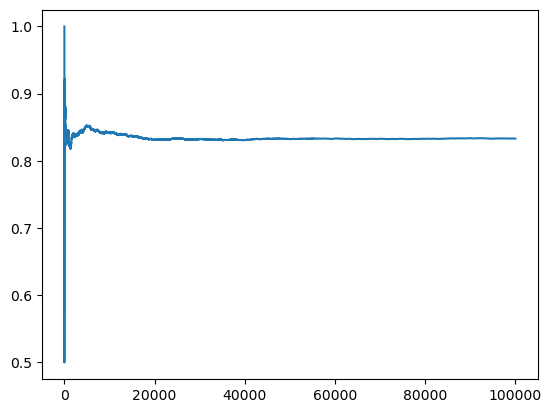

In [4]:
def markow():
    
    weather = [1] #weather of the first day
    
    for ii in tqdm(range(1,100000)):
        # implementing forecasts based on probabilities
        if weather[ii-1] ==1:
            weather.append(np.random.choice(np.array([0,1]), p=np.array([0.1,0.9])))
        elif weather[ii-1] == 0:
            weather.append(np.random.choice(np.array([0,1]), p=np.array([0.5,0.5])))
        else:
            raise ValueError
        
    weather = np.array(weather)
        
    running_clear = np.cumsum(weather)/(np.arange(weather.shape[0])+1)
        
    return running_clear
    
running_clear = markow()
plt.plot(running_clear);

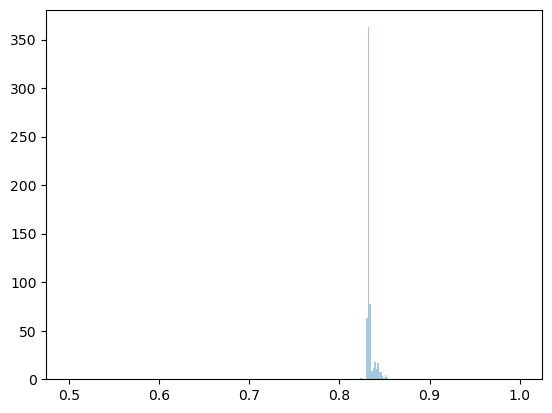

In [5]:
plt.hist(running_clear, bins=300, density=True, alpha=0.4);

In [7]:
print(np.median(running_clear))
print(astroML.stats.sigmaG(running_clear))
print(min(running_clear),max(running_clear))

0.8328741039962893
0.0006995596741144719
0.5 1.0


0.8328714939437751
0.0006781164024580417
0.8306414922656961 0.8524841741799348


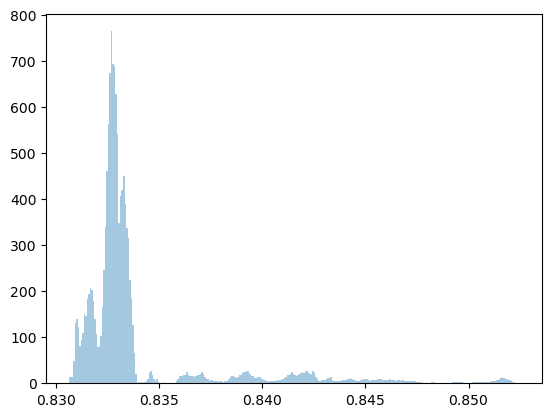

In [9]:
burnin_index = 2000
running_burn = running_clear[burnin_index:]

plt.hist(running_burn, bins=300, density=True, alpha=0.4);
print(np.median(running_burn))
print(astroML.stats.sigmaG(running_burn))
print(min(running_burn), max(running_burn))

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/99999 [00:00<?, ?it/s]

  0%|          | 0/99999 [00:00<?, ?it/s]

  0%|          | 0/99999 [00:00<?, ?it/s]

  0%|          | 0/99999 [00:00<?, ?it/s]

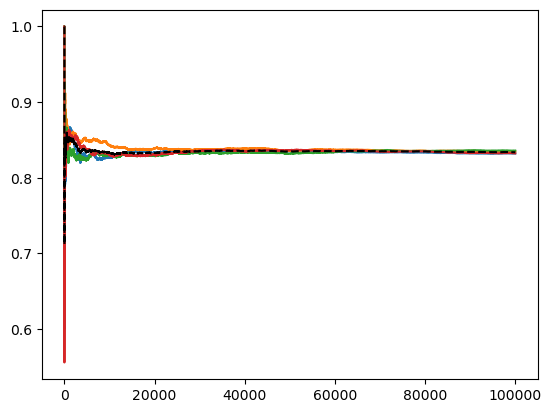

In [11]:
running_clear = np.array([markow() for realization in tqdm(range(4))])

for r in running_clear:
    plt.plot(r)
plt.plot(np.mean(running_clear, axis=0), c='black', ls='dashed');